**Put your name and student ID here**

## GeoPandas

GeoPandas is an open-source library in Python that makes working with geospatial data in pandas easier. It extends the data types used by pandas to include geometry columns, such as points, lines, and polygons, and provides functions for spatial operations on these types. Below is a step-by-step guide to get started with GeoPandas.

 <br/> <a href="https://geopandas.org/en/stable/getting_started/introduction.html" target="_blank">https://geopandas.org/en/stable/getting_started/introduction.html</a>

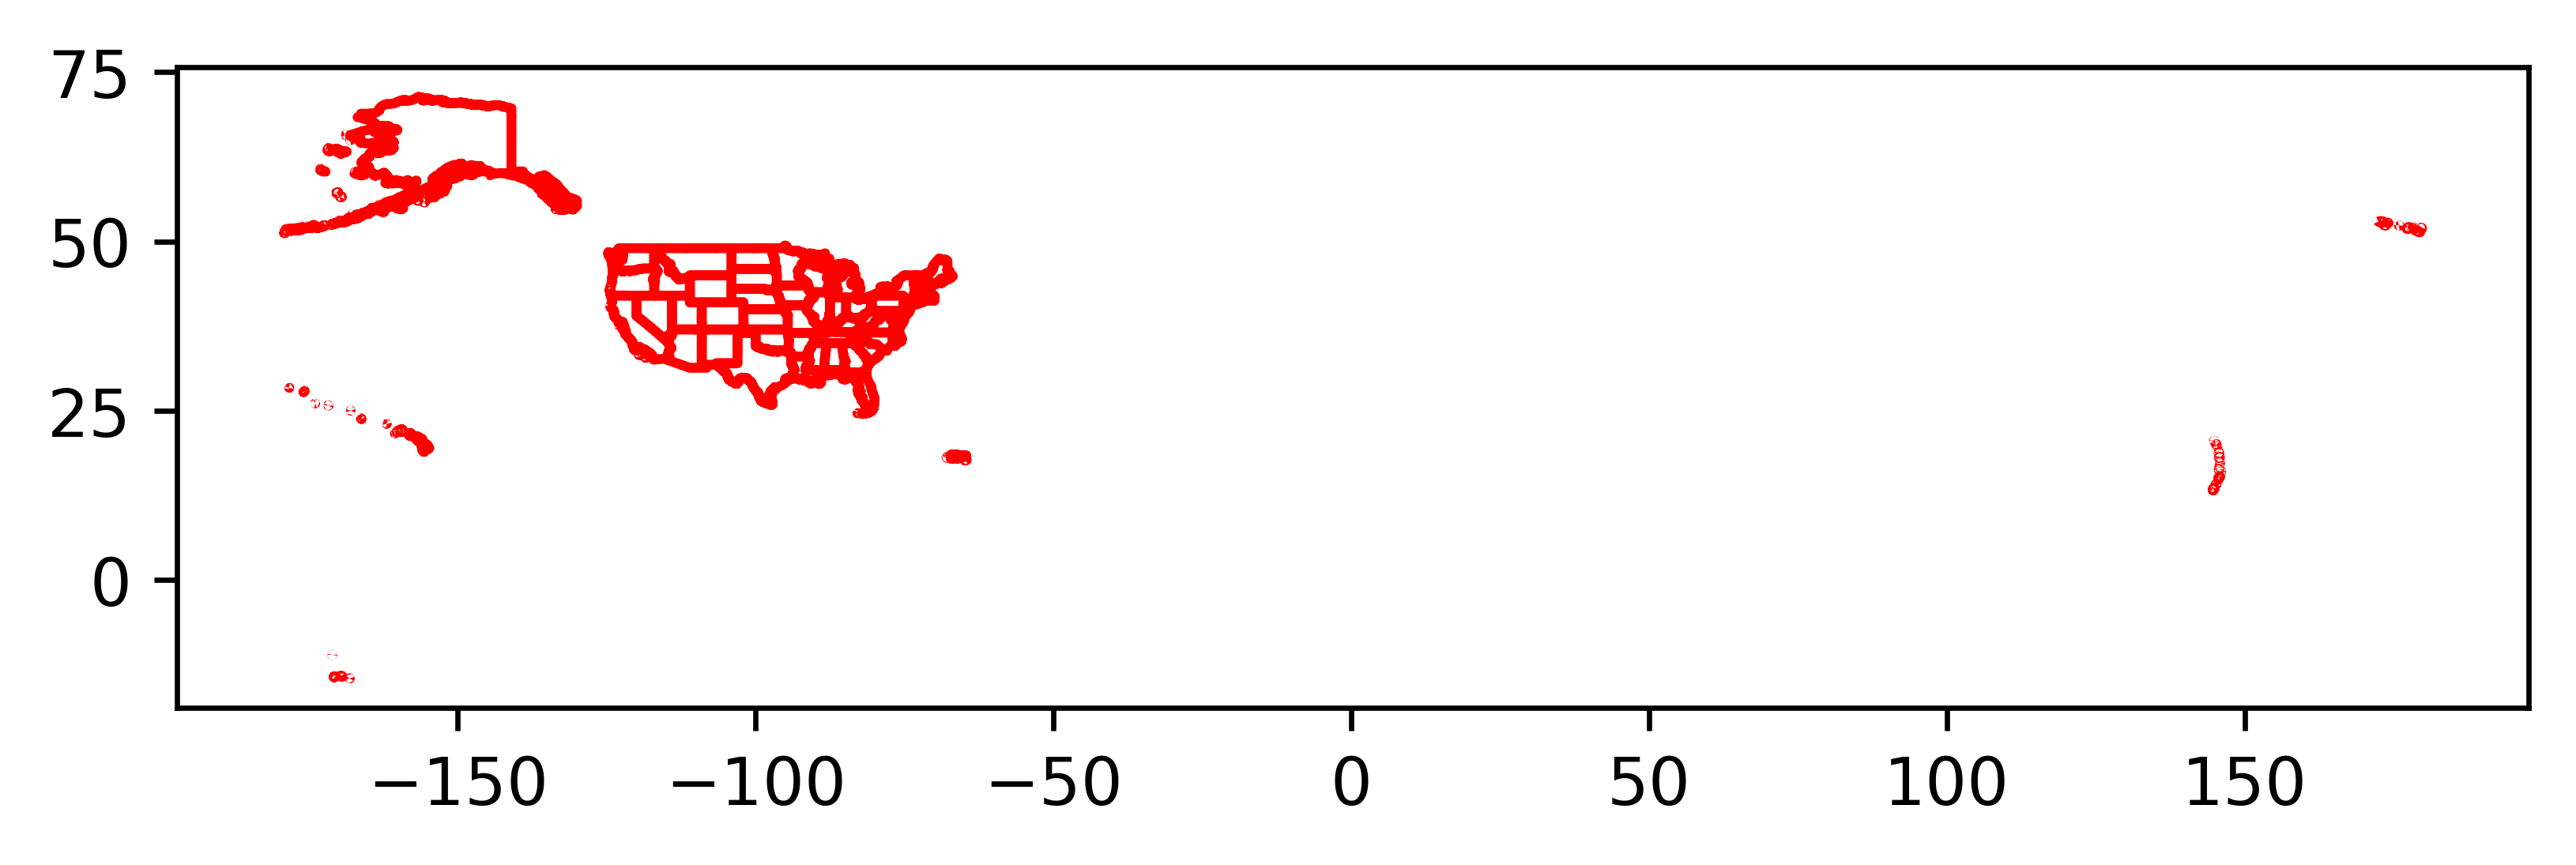

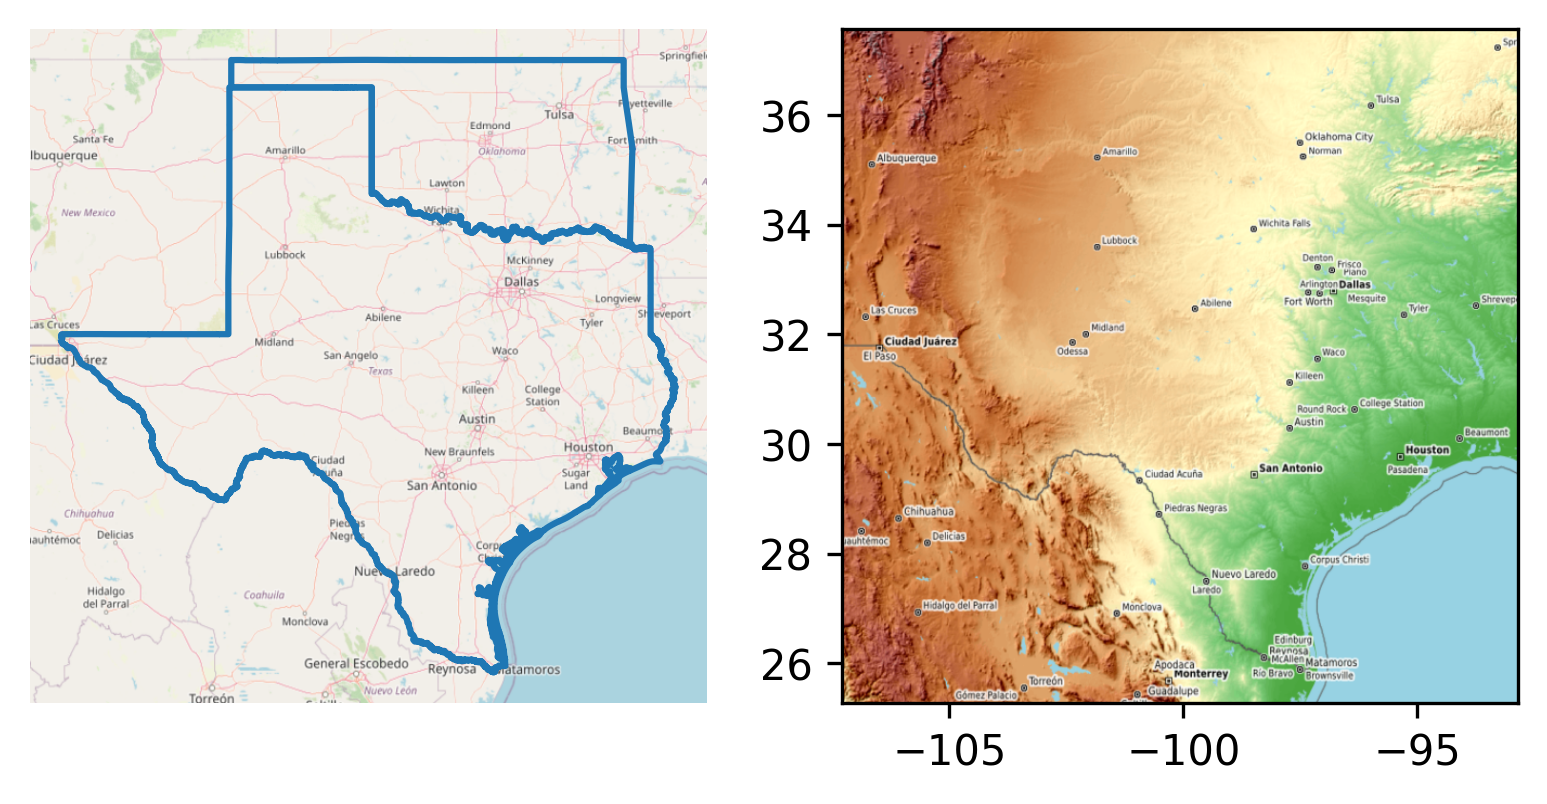

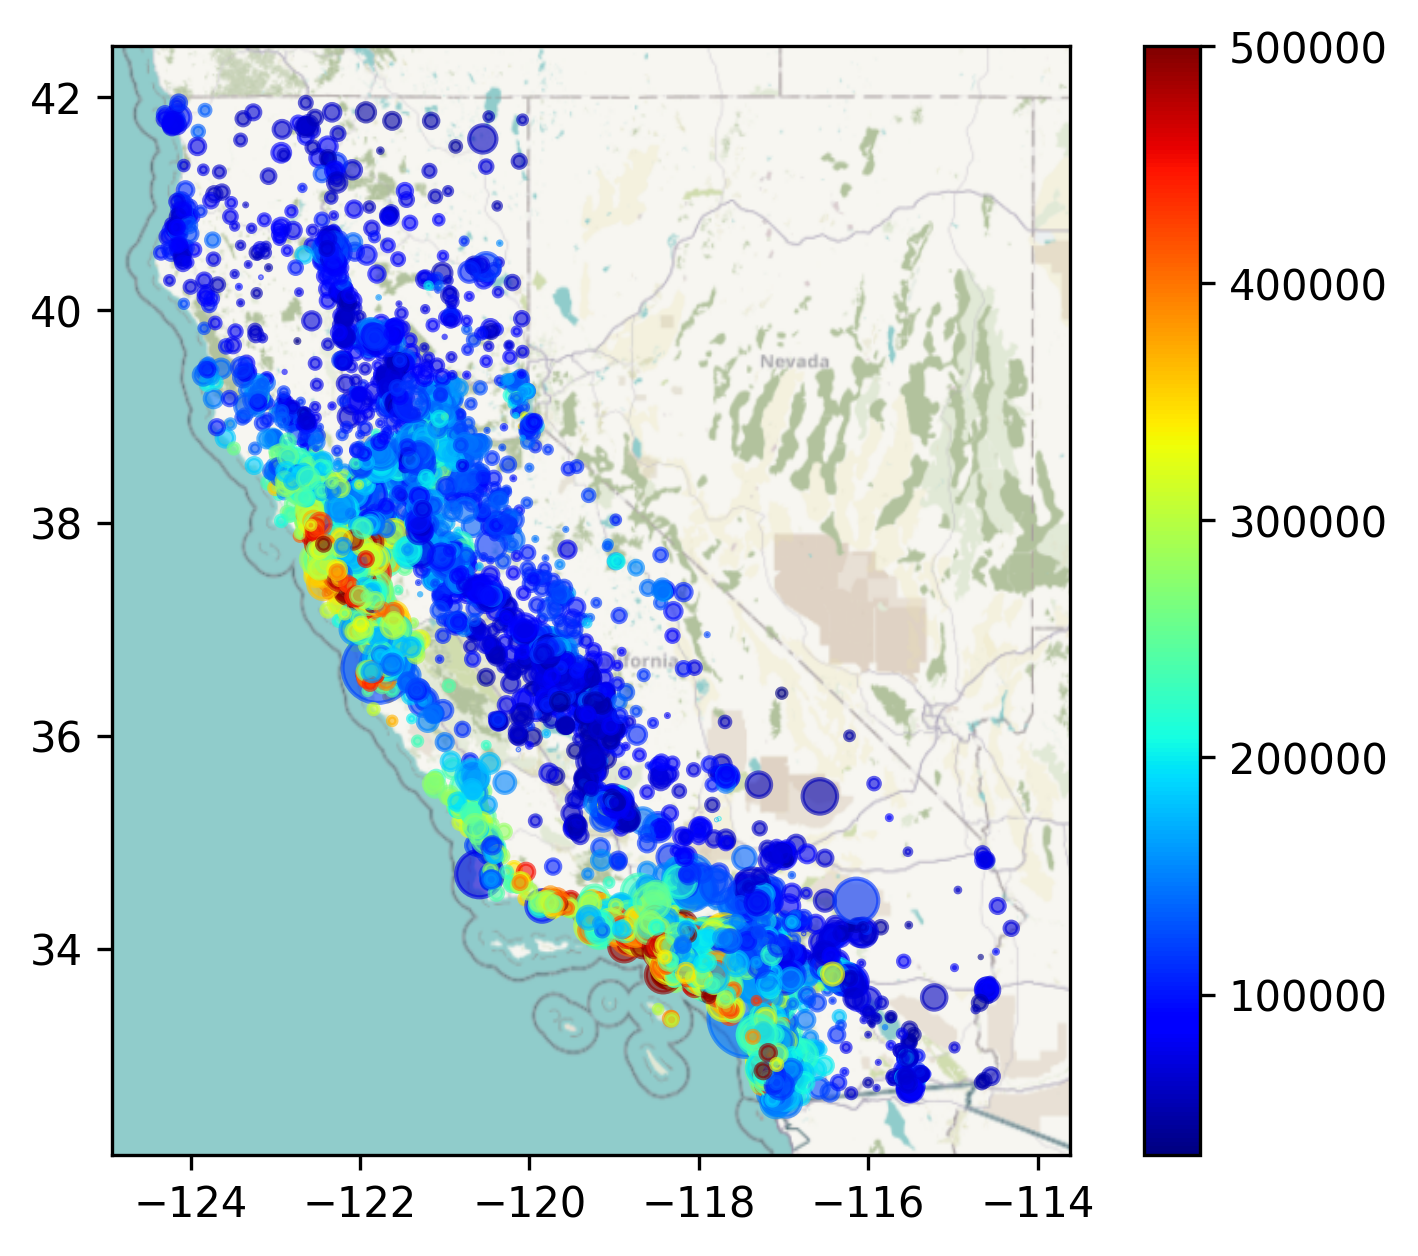

**Installation**
To install GeoPandas, you can use pip or conda (depending on your environment):


```bash
pip install geopandas
```

or


```bash
conda install -c conda-forge geopandas
```
**Importing GeoPandas**

```python
import geopandas as gpd
```
**Loading Geospatial Data**
GeoPandas supports various file formats like Shapefiles, GeoJSON, etc. One of the most common ways to load geospatial data is by using a shapefile.


```python
# Load a shapefile
gdf = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Display the first few rows of the GeoDataFrame
print(gdf.head())
```

This will load a GeoDataFrame containing polygons for countries around the world.
**Exploring the Data**

```python
# Check the columns in the GeoDataFrame
print(gdf.columns)

# Check the coordinate reference system (CRS)
print(gdf.crs)

# Plot the geometries
gdf.plot()
```
**Geometries in GeoPandas**
In GeoPandas, the geometry column can hold different types of geometries like Points, LineStrings, and Polygons.


```python
# Access the geometry column
gdf['geometry'].head()
```

You can also create geometries manually:


```python
from shapely.geometry import Point, Polygon

# Create a Point
point = Point(1, 1)

# Create a Polygon
polygon = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])

# Display the geometries
print(point)
print(polygon)
```
**Spatial Operations**
GeoPandas allows you to perform spatial operations like intersection, union, and distance calculations.


```python
# Filter countries in South America
south_america = gdf[gdf['continent'] == 'South America']

# Plot South America countries
south_america.plot()

# Perform a spatial operation: calculate the area of each country
gdf['area'] = gdf.area
print(gdf[['name', 'area']].head())
```
**Coordinate Reference Systems (CRS)**
Coordinate reference systems define how geometries are mapped to the Earth's surface. GeoPandas makes it easy to reproject geometries.


```python
# Reproject to a different CRS (Mercator projection)
gdf = gdf.to_crs(epsg=3395)

# Check the new CRS
print(gdf.crs)

# Plot the reprojected GeoDataFrame
gdf.plot()
```
**Saving Data**
You can save your GeoDataFrame to a shapefile, GeoJSON, or other formats.


```python
# Save to a shapefile
gdf.to_file("output.shp")

# Save to a GeoJSON
gdf.to_file("output.geojson", driver="GeoJSON")
```
**Combining DataFrames** You can also combine multiple GeoDataFrames using spatial operations like `overlay`, `sjoin` (spatial join), and `concat`.

```python
# Spatial join (e.g., join point data to polygons)
point = gpd.GeoDataFrame(geometry=[Point(-58, -34), Point(-46, -23)], crs="EPSG:4326")
point_in_countries = gpd.sjoin(point, gdf, how="left", op="within")

print(point_in_countries)
```
**Example: Analyzing and Visualizing World Data**

```python
# Load a dataset of world countries
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filter for Africa
africa = world[world['continent'] == 'Africa']

# Plot Africa
africa.plot()

# Calculate and display areas of African countries
africa['area'] = africa.geometry.area
print(africa[['name', 'area']])

# Save the result as GeoJSON
africa.to_file('africa.geojson', driver='GeoJSON')
```
**Visualization with Matplotlib**
You can combine GeoPandas with Matplotlib to create customized plots:


```python
import matplotlib.pyplot as plt

# Plot with Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))
world.boundary.plot(ax=ax)
south_america.plot(ax=ax, color='lightblue')
plt.show()
```
**Conclusion**

GeoPandas simplifies the process of working with geospatial data in Python by extending the functionality of pandas. You can load, manipulate, and visualize geospatial data using familiar pandas operations while performing powerful spatial analysis tasks with ease.

## Contextily

Contextily is a Python library used to add background tiles (basemaps) to geospatial visualizations in Python. It is commonly used in conjunction with geospatial libraries like GeoPandas and Matplotlib. The primary purpose of Contextily is to overlay geospatial data on top of various map tile sources (e.g., OpenStreetMap, Stamen, etc.), which can provide useful geographical context for data visualizations.

**Key Steps to Use Contextily:**

1. **Install Contextily:**
If you don't have it installed yet, you can install it using pip:

```bash
pip install contextily
```

2. **Basic Usage with GeoPandas:**
Once you have a GeoDataFrame (e.g., from shapefiles, GeoJSON, etc.), you can easily plot it on a map and add a basemap using Contextily. Here's a basic example:

```python
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Load geospatial data
gdf = gpd.read_file("your_geospatial_file.shp")

# Plot the data
ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='k')

# Add a basemap
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Stamen.Terrain)

plt.show()
```

**Key Functions of Contextily:**

1. **`add_basemap(ax, zoom=None, crs=None, source=None)`** :
This function adds a basemap to the existing plot. You can customize the zoom level, coordinate reference system (CRS), and the source of the basemap.
  - **`ax`** : The Matplotlib axis to which the basemap will be added.

  - **`zoom`** : (Optional) The zoom level for the map tiles.

  - **`crs`** : (Optional) The CRS of the map. You can use the CRS of your GeoDataFrame.

  - **`source`** : (Optional) The tile provider for the basemap. Contextily has multiple providers, including OpenStreetMap, Stamen, and CartoDB.

2. **Basemap Providers** :
Contextily includes various basemap providers, such as:
  - `ctx.providers.OpenStreetMap.Mapnik`

  - `ctx.providers.Stamen.Terrain`

  - `ctx.providers.CartoDB.Positron`

3. **Handling CRS Transformations** :
Since basemaps are often in web mercator projection (`EPSG:3857`), you might need to reproject your GeoDataFrame to this CRS using:

```python
gdf = gdf.to_crs(epsg=3857)
```

This setup allows you to visualize geospatial data with beautiful, interactive map backgrounds!

## Contextily Basemap Providers

Contextily provides several basemap providers for adding background tiles to geospatial data visualizations in Python. These basemaps are often sourced from online tile providers like OpenStreetMap, Stamen, and others. Here’s an overview of how you can use them and a list of commonly used basemap providers:

**Steps to Use Contextily Basemap Providers**

1. **Install the required packages**  (if you haven't already):

```bash
pip install contextily
```

2. **Basic usage of Contextily** :
You can add a basemap to a geopandas plot using Contextily’s `add_basemap()` function.
Example:


```python
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Load some geospatial data (e.g., a shapefile or GeoDataFrame)
gdf = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Plot the data
ax = gdf.to_crs(epsg=3857).plot(figsize=(10, 10), alpha=0.5, edgecolor='k')

# Add a basemap (default OpenStreetMap)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()
```

**Common Basemap Providers in Contextily**

Here are some of the most frequently used providers in `contextily`:
1. **OpenStreetMap (OSM) Providers** :
  - `ctx.providers.OpenStreetMap.Mapnik`: Default OSM basemap.

  - `ctx.providers.OpenStreetMap.DE`: German OSM style.

  - `ctx.providers.OpenStreetMap.HOT`: OSM's Humanitarian style.

  - `ctx.providers.OpenStreetMap.BlackAndWhite`: Black and white OSM tiles.

2. **Stamen Providers** :
  - `ctx.providers.Stamen.Terrain`: Terrain map tiles.

  - `ctx.providers.Stamen.Toner`: Black-and-white, high-contrast toner map.

  - `ctx.providers.Stamen.Watercolor`: Artistic watercolor style map.

3. **CartoDB Providers** :
  - `ctx.providers.CartoDB.Positron`: Light, minimalistic basemap.

  - `ctx.providers.CartoDB.Voyager`: Detailed basemap with labels.

  - `ctx.providers.CartoDB.DarkMatter`: Dark-themed basemap.

4. **ESRI Providers** :
  - `ctx.providers.Esri.WorldStreetMap`: ESRI's detailed street map.

  - `ctx.providers.Esri.WorldImagery`: Satellite imagery.

  - `ctx.providers.Esri.WorldTopoMap`: Topographic map.

**Customizing the Basemap:**

You can control the zoom level, set the attribution, and choose different basemap styles by selecting a different `source` provider. Here's an example that specifies a Stamen terrain basemap and custom zoom:

```python
ctx.add_basemap(ax, source=ctx.providers.Stamen.Terrain, zoom=10)
```

**Listing Available Providers:**
You can check all available providers by inspecting the `ctx.providers` object:

```python
import contextily as ctx
print(ctx.providers)
```

This will display the full list of available basemap sources that you can use in your project.

## My Code Here

```text
%pip install geopandas
%pip install contextily
%pip install mapclassify
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/ANLY6500Fall2024/LC/M2P3GeoPandas"

/content/drive/MyDrive/Colab Notebooks/ANLY6500Fall2024/LC/M2P3GeoPandas


In [ ]:
%ls

cb_2023_49_bg_500k.zip  GeoPandas_Notes_Finisher.ipynb  Utah_Housing_Inventory_Data.csv
cb_2023_us_all_20m.zip  us-cities-top-1k.csv


In [ ]:
%pwd

'/content/drive/MyDrive/Colab Notebooks/ANLY6500Fall2024/LC/M2P3GeoPandas'

In [ ]:
%pip install geopandas
%pip install contextily
%pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
%ls

cb_2023_49_bg_500k.zip  GeoPandas_Notes_Finisher.ipynb  Utah_Housing_Inventory_Data.csv
cb_2023_us_all_20m.zip  us-cities-top-1k.csv


In [ ]:
df1 = pd.read_csv("us-cities-top-1k.csv")
df1

,City,State,Population,lat,lon
0,Marysville,Washington,63269,48.051764,-122.177082
1,Perris,California,72326,33.782519,-117.228648
2,Cleveland,Ohio,390113,41.499320,-81.694361
3,Worcester,Massachusetts,182544,42.262593,-71.802293
4,Columbia,South Carolina,133358,34.000710,-81.034814
...,...,...,...,...,...
995,West New York,New Jersey,52122,40.787879,-74.014306
996,Everett,Massachusetts,42935,42.408430,-71.053663
997,Linden,New Jersey,41301,40.622048,-74.244590
998,Asheville,North Carolina,87236,35.595058,-82.551487


In [ ]:
df1.columns

Index(['City', 'State', 'Population', 'lat', 'lon'], dtype='object')

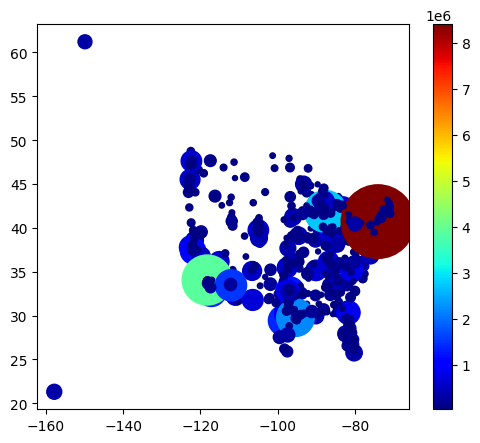

In [ ]:
fig = plt.figure(figsize=(6,5))

ax1 = plt.subplot(1,1,1)

x=df1["lon"]
y=df1["lat"]
pop = df1["Population"]

sc1 = plt.scatter(x,y,c=pop,cmap=plt.cm.jet,s=pop/3000)

plt.colorbar(sc1)

plt.show()

In [ ]:
# GeoPandas

In [ ]:
import geopandas as gpd

In [ ]:
us_gdf = gpd.read_file("usmaps/states/cb_2023_us_state_20m.shx")
us_gdf

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,48,01779801,0400000US48,48,TX,Texas,00,676686238592,18982083586,"POLYGON ((-106.62344 31.91403, -106.63011 31.9..."
1,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.59397 33.4672, -118.48478..."
2,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"POLYGON ((-89.54443 36.57451, -89.47935 36.566..."
3,13,01705317,0400000US13,13,GA,Georgia,00,149485311347,4419673221,"POLYGON ((-85.60516 34.98468, -85.47434 34.983..."
4,55,01779806,0400000US55,55,WI,Wisconsin,00,140292627460,29343084365,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ..."
5,41,01155107,0400000US41,41,OR,Oregon,00,248630419895,6168960338,"POLYGON ((-124.55244 42.84057, -124.48094 42.9..."
6,29,01779791,0400000US29,29,MO,Missouri,00,178052260322,2487519141,"POLYGON ((-95.76564 40.58521, -95.53318 40.582..."
7,51,01779803,0400000US51,51,VA,Virginia,00,102258163252,8528087616,"MULTIPOLYGON (((-76.02348 37.28907, -75.98712 ..."
8,47,01325873,0400000US47,47,TN,Tennessee,00,106792311478,2322248149,"POLYGON ((-90.3007 35.02879, -90.2653 35.04029..."
9,22,01629543,0400000US22,22,LA,Louisiana,00,111930452904,23721187320,"POLYGON ((-94.04305 32.69303, -94.04303 32.797..."


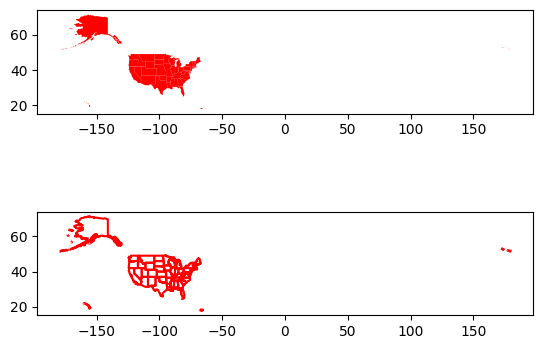

In [ ]:
fig = plt.figure()
# 2 rows 1 column
ax1 = plt.subplot(2,1,1)

us_gdf.plot(ax=ax1,color="red")

ax2 = plt.subplot(2,1,2)
us_gdf.boundary.plot(ax = ax2,color="red")


plt.show()

In [ ]:
us_gdf.head(3)

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,48,01779801,0400000US48,48,TX,Texas,00,676686238592,18982083586,"POLYGON ((-106.62344 31.91403, -106.63011 31.9..."
1,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.59397 33.4672, -118.48478..."
2,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"POLYGON ((-89.54443 36.57451, -89.47935 36.566..."


In [ ]:
us_gdf.columns

Index(['STATEFP', 'STATENS', 'GEOIDFQ', 'GEOID', 'STUSPS', 'NAME', 'LSAD',
       'ALAND', 'AWATER', 'geometry'],
      dtype='object')

In [ ]:
us_gdf.set_index(['STUSPS'],drop=False,inplace=True)

In [ ]:
us_gdf.head(5)

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
STUSPS,,,,,,,,,,
TX,48,01779801,0400000US48,48,TX,Texas,00,676686238592,18982083586,"POLYGON ((-106.62344 31.91403, -106.63011 31.9..."
CA,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.59397 33.4672, -118.48478..."
KY,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"POLYGON ((-89.54443 36.57451, -89.47935 36.566..."
GA,13,01705317,0400000US13,13,GA,Georgia,00,149485311347,4419673221,"POLYGON ((-85.60516 34.98468, -85.47434 34.983..."
WI,55,01779806,0400000US55,55,WI,Wisconsin,00,140292627460,29343084365,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ..."


In [ ]:
us_gdf.loc[["TX","OK"]]

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
STUSPS,,,,,,,,,,
TX,48,01779801,0400000US48,48,TX,Texas,00,676686238592,18982083586,"POLYGON ((-106.62344 31.91403, -106.63011 31.9..."
OK,40,01102857,0400000US40,40,OK,Oklahoma,00,177664484361,3373395450,"POLYGON ((-103.00252 36.67519, -103.00196 36.9..."


In [ ]:
ut_nv_gdf=us_gdf.loc[["UT","NV"]]
ut_nv_gdf

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
STUSPS,,,,,,,,,,
UT,49,01455989,0400000US49,49,UT,Utah,00,213921849163,5963196691,"POLYGON ((-114.05247 37.60478, -114.05173 37.7..."
NV,32,01779793,0400000US32,32,NV,Nevada,00,284537045712,1839880833,"POLYGON ((-120.0048 39.31648, -120.00303 39.44..."


In [ ]:
import contextily as ctx

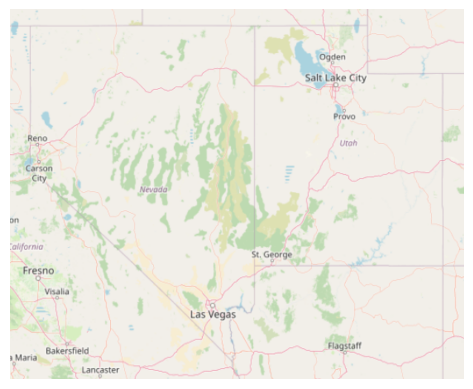

In [ ]:
fig = plt.figure()

ax1 =plt.subplot(1,1,1)

ut_nv_gdf.boundary.plot(ax = ax1,color="none")
# CRS: coordinate reference system
ctx.add_basemap(ax=ax1,crs=ut_nv_gdf.crs,source=ctx.providers.OpenStreetMap.Mapnik,attribution="")

plt.axis(False)

plt.show()

In [ ]:
#
df1

,City,State,Population,lat,lon
0,Marysville,Washington,63269,48.051764,-122.177082
1,Perris,California,72326,33.782519,-117.228648
2,Cleveland,Ohio,390113,41.499320,-81.694361
3,Worcester,Massachusetts,182544,42.262593,-71.802293
4,Columbia,South Carolina,133358,34.000710,-81.034814
...,...,...,...,...,...
995,West New York,New Jersey,52122,40.787879,-74.014306
996,Everett,Massachusetts,42935,42.408430,-71.053663
997,Linden,New Jersey,41301,40.622048,-74.244590
998,Asheville,North Carolina,87236,35.595058,-82.551487


In [ ]:
x=df1["lon"]
y=df1["lat"]
df1_gdf = gpd.GeoDataFrame(df1,crs=us_gdf.crs,geometry=gpd.points_from_xy(x,y))
df1_gdf

,City,State,Population,lat,lon,geometry
0,Marysville,Washington,63269,48.051764,-122.177082,POINT (-122.17708 48.05176)
1,Perris,California,72326,33.782519,-117.228648,POINT (-117.22865 33.78252)
2,Cleveland,Ohio,390113,41.499320,-81.694361,POINT (-81.69436 41.49932)
3,Worcester,Massachusetts,182544,42.262593,-71.802293,POINT (-71.80229 42.26259)
4,Columbia,South Carolina,133358,34.000710,-81.034814,POINT (-81.03481 34.00071)
...,...,...,...,...,...,...
995,West New York,New Jersey,52122,40.787879,-74.014306,POINT (-74.01431 40.78788)
996,Everett,Massachusetts,42935,42.408430,-71.053663,POINT (-71.05366 42.40843)
997,Linden,New Jersey,41301,40.622048,-74.244590,POINT (-74.24459 40.62205)
998,Asheville,North Carolina,87236,35.595058,-82.551487,POINT (-82.55149 35.59506)


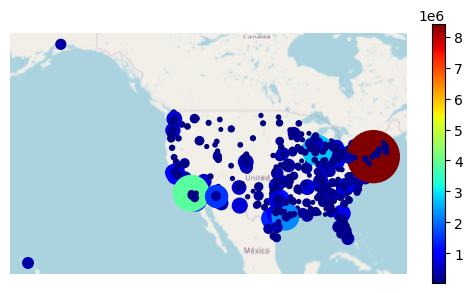

In [ ]:
fig = plt.figure()

ax1 =plt.subplot(1,1,1)

pop=df1_gdf["Population"]

df1_gdf.plot(ax = ax1,column=pop,cmap=plt.cm.jet,legend=True,legend_kwds={"shrink":0.7,},markersize=pop/6000)

ctx.add_basemap(ax = ax1,crs=df1_gdf.crs,source=ctx.providers.OpenStreetMap.Mapnik,attribution="")

plt.axis(False)

plt.savefig("fig1.png",dpi=600)

plt.show()